# Validation: 100% Momentum vs 100% Value

This notebook loads MSCI World Momentum and Enhanced Value index data, runs several allocation strategies, and compares performance metrics and plots.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from asset_allocation.backtest import run_backtest
from asset_allocation.config import BacktestConfig
from asset_allocation.data import load_prices
from asset_allocation.metrics import calendar_year_returns, summary
from asset_allocation.plotting import (
    plot_allocation,
    plot_drawdown,
    plot_equity_curve,
    plot_return_distribution,
    plot_summary,
)
from asset_allocation.strategy import (
    buy_and_hold_weights,
    constant_weights,
    periodic_weights,
)

%matplotlib inline

## Load joint price table

Observations: 342  |  1997-12-31 -> 2026-05-29


,momentum,value
date,,
1997-12-31,384.240,197.889
1998-01-30,395.305,198.355
1998-02-27,421.292,223.488
1998-03-31,449.527,231.302
1998-04-30,459.902,225.184


,momentum,value
date,,
2026-01-30,5867.020,2503.776
2026-02-27,5918.340,2614.480
2026-03-31,5427.098,2411.618
2026-04-30,6334.504,2744.064
2026-05-29,6825.896,3143.845


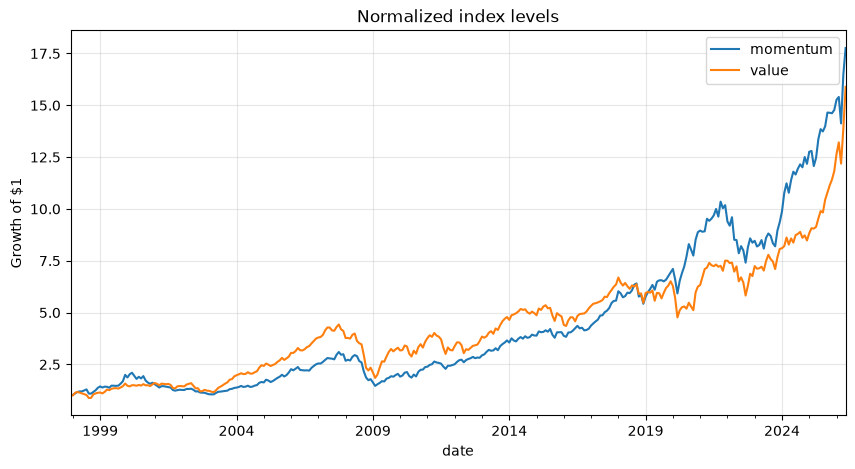

In [2]:
prices = load_prices()
print(f"Observations: {len(prices)}  |  {prices.index[0].date()} -> {prices.index[-1].date()}")
display(prices.head())
display(prices.tail())

ax = prices.div(prices.iloc[0]).plot(figsize=(10, 5), title="Normalized index levels")
ax.set_ylabel("Growth of $1")
ax.grid(True, alpha=0.3)
plt.show()

## Define strategies

- **100% momentum / 100% value**: constant target weights (rebalanced when targets change)
- **50/50 annual**: rebalance to equal weights at each year-end observation
- **50/50 buy-and-hold**: initial 50/50 allocation, no further rebalancing

In [3]:
strategies = {
    "100% momentum": constant_weights(prices, {"momentum": 1.0}),
    "100% value": constant_weights(prices, {"value": 1.0}),
    "50/50 annual": periodic_weights(prices, {"momentum": 0.5, "value": 0.5}, freq="Y"),
    "50/50 buy-and-hold": buy_and_hold_weights(prices, {"momentum": 0.5, "value": 0.5}),
}

config_default = BacktestConfig()
config_no_friction = BacktestConfig(apply_taxes=False, apply_transaction_costs=False)

## Run backtests (with German taxes & costs)

In [4]:
results = {
    name: run_backtest(prices, weights, config_default)
    for name, weights in strategies.items()
}

summary_df = pd.concat([summary(r, name) for name, r in results.items()])
summary_df.style.format(
    {
        "total_return": "{:.1%}",
        "cagr": "{:.1%}",
        "annual_volatility": "{:.1%}",
        "sharpe_ratio": "{:.2f}",
        "sortino_ratio": "{:.2f}",
        "calmar_ratio": "{:.2f}",
        "max_drawdown": "{:.1%}",
        "best_month": "{:.1%}",
        "worst_month": "{:.1%}",
        "win_rate": "{:.1%}",
        "annual_turnover": "{:.2f}",
        "time_in_market": "{:.1%}",
        "total_taxes": "{:,.0f}",
        "total_costs": "{:,.0f}",
    },
    na_rep="-",
)

,total_return,cagr,annual_volatility,sharpe_ratio,sortino_ratio,calmar_ratio,max_drawdown,longest_drawdown_months,best_month,worst_month,win_rate,annual_turnover,time_in_market,num_trades,total_taxes,total_costs
name,,,,,,,,,,,,,,,,
100% momentum,1676.5%,10.7%,16.2%,0.71,0.99,0.20,-52.8%,68,18.2%,-16.7%,62.2%,0.01,100.0%,1,0,10
100% value,1488.7%,10.2%,17.9%,0.64,0.89,0.18,-58.2%,71,18.6%,-20.9%,60.4%,0.01,100.0%,1,0,10
50/50 annual,1681.6%,10.7%,16.1%,0.71,0.97,0.19,-55.6%,68,15.2%,-17.2%,63.3%,0.07,100.0%,60,"5,204",90
50/50 buy-and-hold,1582.6%,10.4%,16.2%,0.70,0.95,0.19,-56.0%,70,15.4%,-17.8%,62.5%,0.01,100.0%,2,0,10


## Sanity check: single-asset buy-and-hold without friction

With taxes and costs disabled, a 100% momentum portfolio should track the momentum index exactly.

In [5]:
momentum_bh = run_backtest(
    prices,
    constant_weights(prices, {"momentum": 1.0}),
    config_no_friction,
)

normalized_equity = momentum_bh.equity / momentum_bh.equity.iloc[0]
normalized_index = prices["momentum"] / prices["momentum"].iloc[0]
max_tracking_error = (normalized_equity - normalized_index).abs().max()

print(f"Max tracking error vs momentum index: {max_tracking_error:.2e}")
print(f"Number of trades (should be 1): {momentum_bh.num_trades}")

Max tracking error vs momentum index: 1.78e-15
Number of trades (should be 1): 1


## Plots

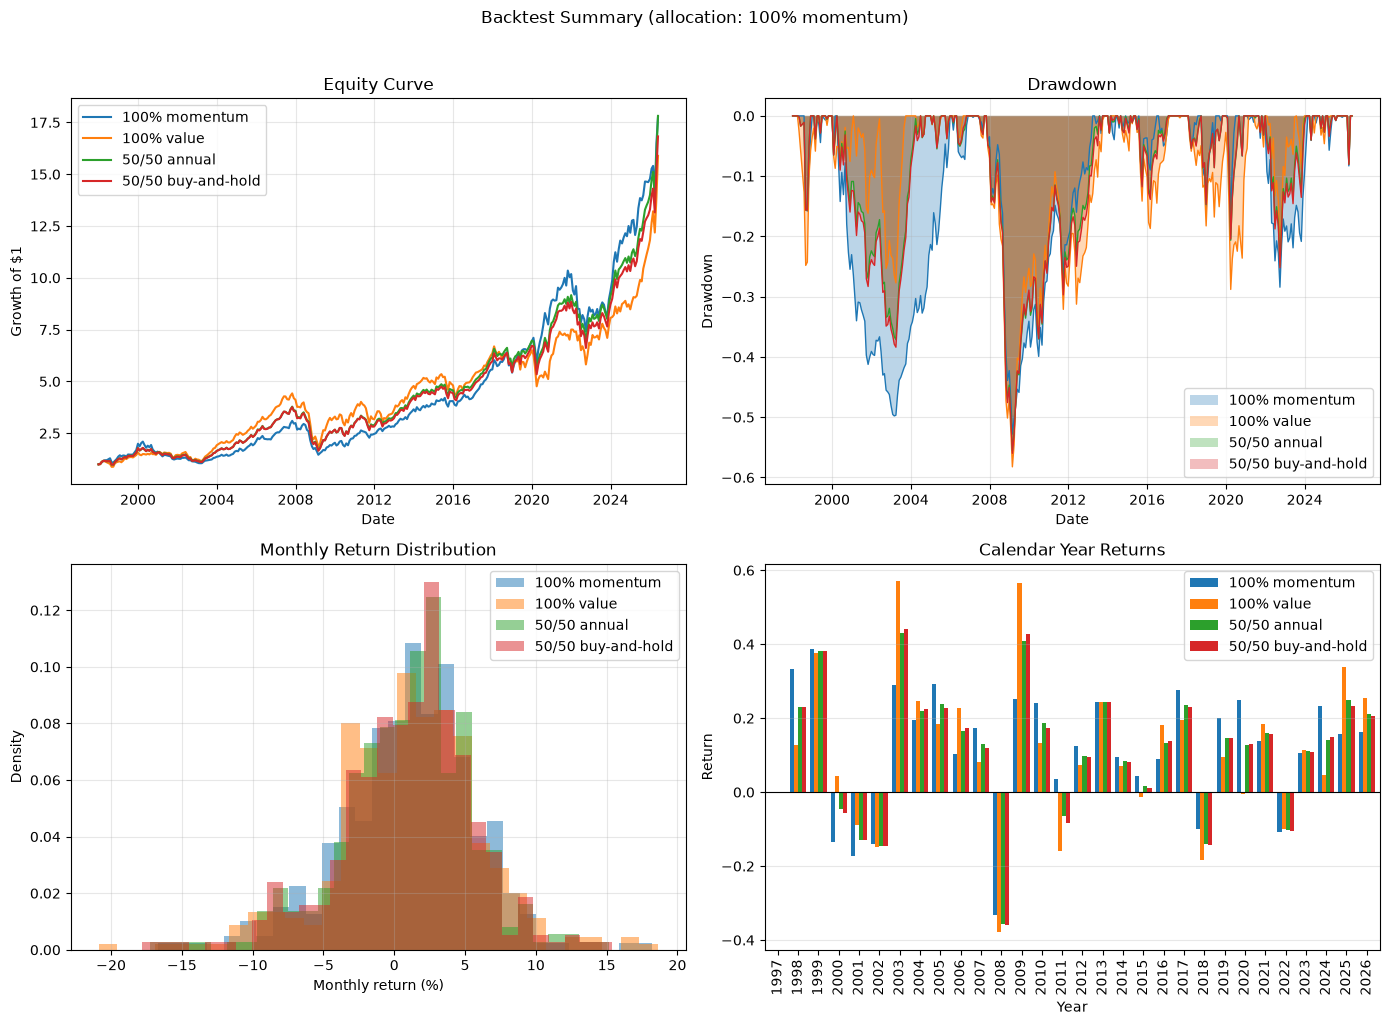

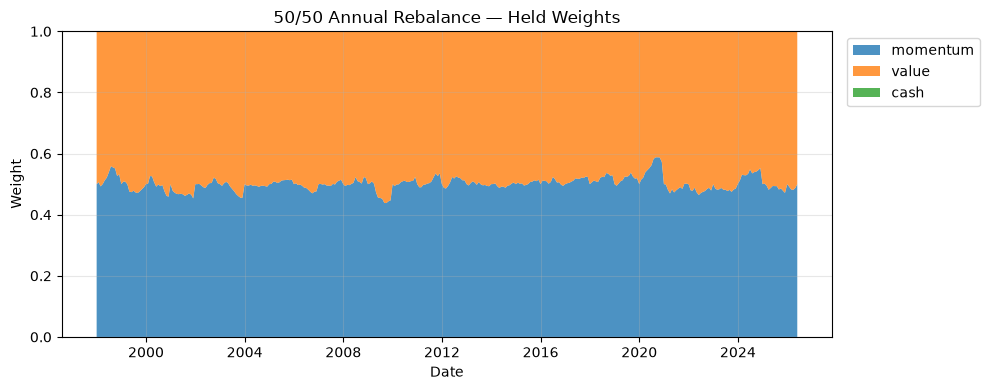

In [6]:
plot_summary(results)
plt.show()

plot_allocation(results["50/50 annual"], title="50/50 Annual Rebalance — Held Weights")
plt.show()

## Calendar year returns (momentum vs value)

In [7]:
core = {k: results[k] for k in ["100% momentum", "100% value"]}
yearly = pd.DataFrame({name: calendar_year_returns(r) for name, r in core.items()})
yearly.tail(10)

,100% momentum,100% value
year,,
2017,0.275215,0.193989
2018,-0.100165,-0.182571
2019,0.200155,0.095278
2020,0.249715,-0.005169
2021,0.137066,0.185454
2022,-0.108979,-0.098613
2023,0.105641,0.114242
2024,0.232650,0.046229
2025,0.157742,0.338603
